In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
project = "/content/drive/MyDrive/Machine_Learning/SIGNATECup_2026"
train = pd.read_csv(project + "/data/train.csv")
test = pd.read_csv(project + "/data/test.csv")

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 43 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   企業ID                742 non-null    int64  
 1   企業名                 742 non-null    object 
 2   従業員数                742 non-null    int64  
 3   業界                  742 non-null    object 
 4   上場種別                742 non-null    object 
 5   特徴                  740 non-null    object 
 6   企業概要                742 non-null    object 
 7   組織図                 742 non-null    object 
 8   事業所数                726 non-null    float64
 9   工場数                 339 non-null    float64
 10  店舗数                 139 non-null    float64
 11  資本金                 736 non-null    float64
 12  総資産                 742 non-null    int64  
 13  流動資産                742 non-null    int64  
 14  固定資産                742 non-null    int64  
 15  負債                  742 non-null    int64  
 16  短期借入金   

In [4]:
train.shape

(742, 43)

In [5]:
import os
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score

import warnings
warnings.filterwarnings("ignore")

SEED = 42
TARGET = "購入フラグ"

print("lightgbm:", lgb.__version__)

lightgbm: 4.6.0


In [6]:
print(train[TARGET].value_counts())
print("正例率:", round(train[TARGET].mean(), 4))

購入フラグ
0    563
1    179
Name: count, dtype: int64
正例率: 0.2412


In [7]:
info = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "nunique": train.nunique(),
    "null": train.isna().sum(),
    "null_rate(%)": (train.isna().mean() * 100).round(2),
})
info.sort_values("null_rate(%)", ascending=False).head(15)

,dtype,nunique,null,null_rate(%)
店舗数,float64,103,603,81.27
工場数,float64,28,403,54.31
アンケート７,float64,5,356,47.98
経常利益,float64,646,83,11.19
営業利益,float64,694,43,5.80
事業所数,float64,97,16,2.16
資本金,float64,701,6,0.81
特徴,object,5,2,0.27
従業員数,int64,659,0,0.00
企業ID,int64,742,0,0.00


In [8]:
print("=== アンケート６ × アンケート７の欠損 ===")
print(pd.crosstab(train["アンケート６"], train["アンケート７"].isna()))

print("\n=== 業界別 工場数/店舗数の欠損率 ===")
g = train.groupby("業界").apply(
    lambda d: pd.Series({
        "n": len(d),
        "工場数_欠損率": d["工場数"].isna().mean().round(2),
        "店舗数_欠損率": d["店舗数"].isna().mean().round(2),
    })
).sort_values("n", ascending=False)
print(g.head(10))

print("\n=== 欠損の有無と正例率（全体 %.3f） ===" % train[TARGET].mean())
for c in ["事業所数", "工場数", "店舗数", "資本金", "営業利益", "経常利益", "アンケート７"]:
    m = train[c].isna()
    print(f"{c:8s} 欠損時={train.loc[m, TARGET].mean():.3f} (n={m.sum():4d})"
          f"  非欠損時={train.loc[~m, TARGET].mean():.3f}")

=== アンケート６ × アンケート７の欠損 ===
アンケート７  False  True 
アンケート６              
1         386      0
2           0    356

=== 業界別 工場数/店舗数の欠損率 ===
             n  工場数_欠損率  店舗数_欠損率
業界                              
機械       106.0     0.22     0.93
IT        62.0     0.94     0.95
金融        57.0     1.00     0.81
建設・工事     55.0     0.53     0.85
自動車・乗り物   49.0     0.10     0.96
小売        41.0     0.76     0.15
製造        39.0     0.21     1.00
商社        35.0     0.49     0.86
化学        31.0     0.13     0.97
食品        25.0     0.20     0.72

=== 欠損の有無と正例率（全体 0.241） ===
事業所数     欠損時=0.188 (n=  16)  非欠損時=0.242
工場数      欠損時=0.251 (n= 403)  非欠損時=0.230
店舗数      欠損時=0.269 (n= 603)  非欠損時=0.122
資本金      欠損時=0.000 (n=   6)  非欠損時=0.243
営業利益     欠損時=0.349 (n=  43)  非欠損時=0.235
経常利益     欠損時=0.398 (n=  83)  非欠損時=0.222
アンケート７   欠損時=0.222 (n= 356)  非欠損時=0.259


In [9]:
DROP_TEXT = ["企業ID", "企業名", "企業概要", "組織図", "今後のDX展望"]
CAT_COLS  = ["業界", "上場種別", "特徴"]

ZERO_FILL = ["事業所数", "工場数", "店舗数", "アンケート７"]  # 0埋め + フラグ
FLAG_ONLY = ["資本金", "営業利益", "経常利益"]                # NaNのまま + フラグ


def preprocess(df, cat_categories=None):
    df = df.copy()
    df = df.drop(columns=[c for c in DROP_TEXT if c in df.columns])

    # 構造的欠損: 0埋め + 欠損フラグ列を別に作る
    for c in ZERO_FILL:
        df[f"{c}_isna"] = df[c].isna().astype(int)
        df[c] = df[c].fillna(0)

    # 財務欠損: 値はNaNのまま、フラグ列だけ追加
    for c in FLAG_ONLY:
        df[f"{c}_isna"] = df[c].isna().astype(int)

    # カテゴリ列（train/testでカテゴリ定義を揃える）
    for c in CAT_COLS:
        if cat_categories is None:
            df[c] = df[c].astype("category")
        else:
            df[c] = pd.Categorical(df[c], categories=cat_categories[c])

    return df


train_p = preprocess(train)
cat_categories = {c: train_p[c].cat.categories for c in CAT_COLS}

y = train_p[TARGET].values
X = train_p.drop(columns=[TARGET])

print("処理後 shape:", X.shape)
print("追加した欠損フラグ列:", [c for c in X.columns if c.endswith("_isna")])
X.head(3)

処理後 shape: (742, 44)
追加した欠損フラグ列: ['事業所数_isna', '工場数_isna', '店舗数_isna', 'アンケート７_isna', '資本金_isna', '営業利益_isna', '経常利益_isna']


,従業員数,業界,上場種別,特徴,事業所数,工場数,店舗数,資本金,総資産,流動資産,...,アンケート９,アンケート１０,アンケート１１,事業所数_isna,工場数_isna,店舗数_isna,アンケート７_isna,資本金_isna,営業利益_isna,経常利益_isna
0,4539,化学,PR,BtoB,2.0,10.0,1.0,98364.0,1248827,561053,...,4,1,1,0,0,0,1,0,0,0
1,792,運輸・物流,PR,BtoB,2.0,0.0,0.0,128400.0,2491660,1024551,...,1,2,1,0,1,1,0,0,0,0
2,4346,建設・工事,PR,BtoB,24.0,0.0,0.0,7143.0,530553,204244,...,1,1,2,0,1,1,0,0,0,0


In [10]:
params = dict(
    objective="binary",
    metric="binary_logloss",
    learning_rate=0.03,
    num_leaves=15,          # 742行なので浅め
    min_child_samples=20,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    lambda_l2=1.0,
    verbosity=-1,
    seed=SEED,
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof = np.zeros(len(X))
models = []
importances = np.zeros(X.shape[1])

for fold, (tr, va) in enumerate(skf.split(X, y)):
    dtr = lgb.Dataset(X.iloc[tr], y[tr])
    dva = lgb.Dataset(X.iloc[va], y[va])
    model = lgb.train(
        params, dtr, num_boost_round=2000, valid_sets=[dva],
        callbacks=[lgb.early_stopping(100, verbose=False)],
    )
    oof[va] = model.predict(X.iloc[va], num_iteration=model.best_iteration)
    models.append(model)
    importances += model.feature_importance("gain") / skf.n_splits
    print(f"fold {fold}: best_iter={model.best_iteration:4d} "
          f"AUC={roc_auc_score(y[va], oof[va]):.4f}")

print("\nOOF AUC:", round(roc_auc_score(y, oof), 4))

fold 0: best_iter= 406 AUC=0.9095
fold 1: best_iter= 286 AUC=0.8412
fold 2: best_iter= 162 AUC=0.8425
fold 3: best_iter= 192 AUC=0.8313
fold 4: best_iter= 300 AUC=0.8708

OOF AUC: 0.8621


In [11]:
ths = np.arange(0.05, 0.95, 0.005)
f1s = np.array([f1_score(y, (oof >= t).astype(int)) for t in ths])

best_i = int(f1s.argmax())
BEST_TH, best_f1 = ths[best_i], f1s[best_i]

print(f"F1 @ 0.5            : {f1_score(y, (oof >= 0.5).astype(int)):.4f}")
print(f"F1 @ best({BEST_TH:.3f}) : {best_f1:.4f}")

# fold毎に閾値を決めた場合のブレ（閾値が信用できるかの確認）
fold_ths = []
for tr, va in skf.split(X, y):
    f = [f1_score(y[va], (oof[va] >= t).astype(int)) for t in ths]
    fold_ths.append(ths[int(np.argmax(f))])
print("fold毎の最適閾値:", np.round(fold_ths, 3))

F1 @ 0.5            : 0.5429
F1 @ best(0.220) : 0.6667
fold毎の最適閾値: [0.23 0.22 0.22 0.18 0.21]


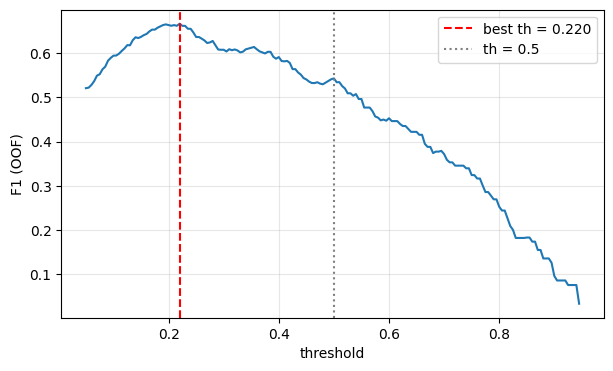

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(ths, f1s)
plt.axvline(BEST_TH, color="red", linestyle="--", label=f"best th = {BEST_TH:.3f}")
plt.axvline(0.5, color="gray", linestyle=":", label="th = 0.5")
plt.xlabel("threshold")
plt.ylabel("F1 (OOF)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [14]:
imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
print(imp.head(20).round(1).to_string())

無形固定資産変動(ソフトウェア関連)    1167.8
業界                     554.4
長期借入金                  493.3
負債                     464.2
売上                     384.5
当期純利益                  378.1
営業利益                   360.7
従業員数                   350.3
アンケート１０                339.7
アンケート４                 322.8
短期借入金                  320.5
資本金                    294.1
経常利益                   292.2
アンケート７                 273.3
アンケート２                 267.0
営業CF                   244.4
事業所数                   243.3
固定資産                   195.7
アンケート８                 188.4
純資産                    161.8


In [15]:
test_p = preprocess(test, cat_categories=cat_categories)
test_p = test_p.drop(columns=[TARGET], errors="ignore")
test_p = test_p[X.columns]   # 列順をtrainに合わせる

pred_proba = np.mean(
    [m.predict(test_p, num_iteration=m.best_iteration) for m in models], axis=0
)
pred_label = (pred_proba >= BEST_TH).astype(int)

print("予測した正例率:", round(pred_label.mean(), 4), "/ 学習データ:", round(y.mean(), 4))
print(pd.Series(pred_label).value_counts())

予測した正例率: 0.3162 / 学習データ: 0.2412
0    547
1    253
Name: count, dtype: int64


In [16]:
sub_dir = project + "/submission"
os.makedirs(sub_dir, exist_ok=True)

# 提出形式の基準としてsample_submitを読む（ヘッダなし・2列）
sample = pd.read_csv(project + "/data/sample_submit.csv",
                     header=None, names=["企業ID", "購入フラグ"])

# 予測をIDで突合し、sample_submitの行順に完全に合わせる
pred_df = pd.DataFrame({"企業ID": test["企業ID"].values, "pred": pred_label})
sub = sample[["企業ID"]].merge(pred_df, on="企業ID", how="left")

# 提出前チェック
assert len(sub) == len(sample), f"行数不一致: {len(sub)} != {len(sample)}"
assert sub["pred"].notna().all(), "予測が欠けているIDがあります"
sub["pred"] = sub["pred"].astype(int)

sub_path = sub_dir + "/submission_baseline.csv"
sub.to_csv(sub_path, index=False, header=False, lineterminator="\n")

print("保存先:", sub_path)
print("行数:", len(sub), "/ sample:", len(sample))
print("予測の内訳:")
print(sub["pred"].value_counts().to_string())
print("先頭3行:", open(sub_path).read().split("\n")[:3])

保存先: /content/drive/MyDrive/Machine_Learning/SIGNATECup_2026/submission/submission_baseline.csv
行数: 800 / sample: 800
予測の内訳:
pred
0    547
1    253
先頭3行: ['742,1', '743,0', '744,0']
